# Sampling and inference

A trained model returns logits. Decoding is a separate procedure that turns those logits into the next token. Temperature, top-k, and top-p change the sampling rule while leaving the model unchanged.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F
SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
logits = torch.tensor([3.0, 2.0, 1.0, 0.2])
labels = ['the', ' a', ' cat', '.']

def probabilities(logits, temperature=1.0):
    return torch.softmax(logits / temperature, dim=-1)
for temperature in (0.5, 1.0, 1.5):
    print(temperature, dict(zip(labels, probabilities(logits, temperature).tolist())))

0.5 {'the': 0.8640437126159668, ' a': 0.116935595870018, ' cat': 0.015825513750314713, '.': 0.003195116063579917}
1.0 {'the': 0.6393760442733765, ' a': 0.23521330952644348, ' cat': 0.08653013408184052, '.': 0.03888050094246864}
1.5 {'the': 0.517691433429718, ' a': 0.265791654586792, ' cat': 0.1364619880914688, '.': 0.08005490154027939}


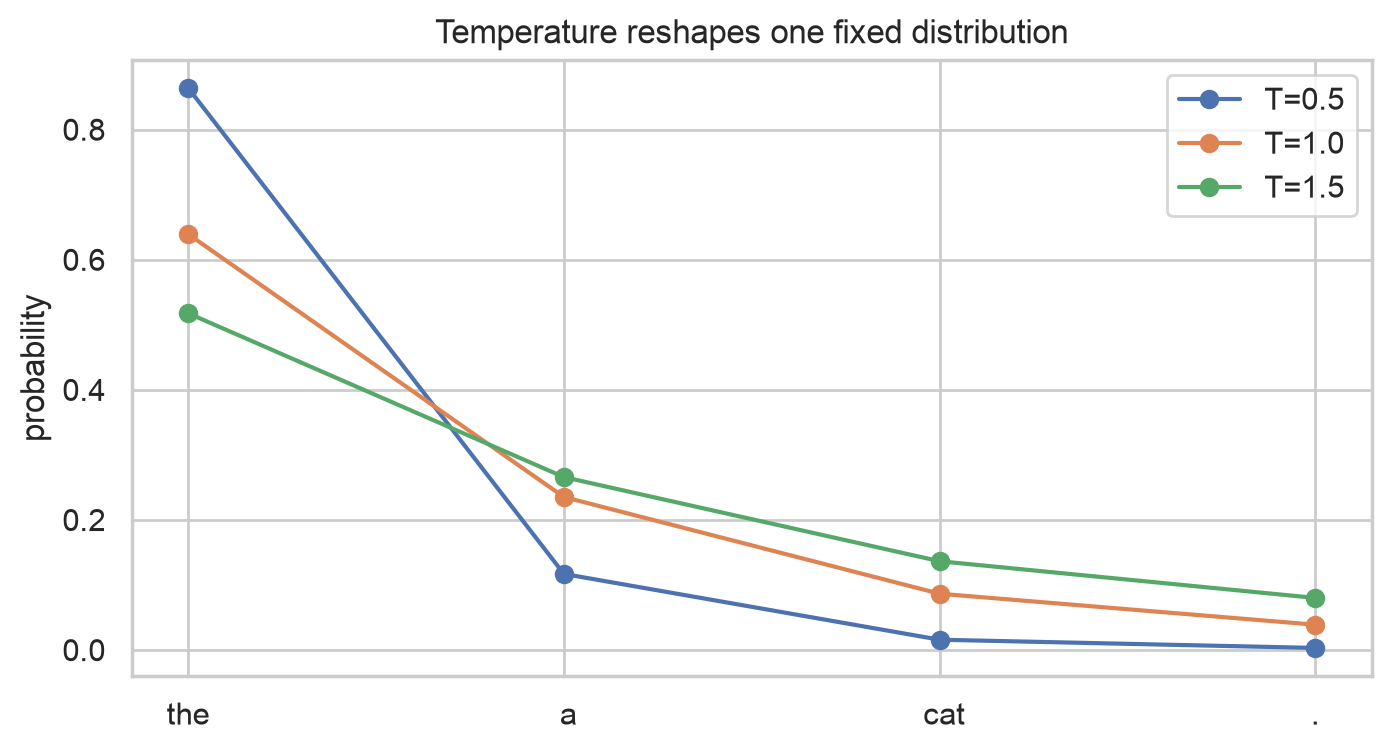

In [3]:
temperatures = [0.5, 1.0, 1.5]
fig, ax = plt.subplots(figsize=(8, 4))
for t in temperatures:
    ax.plot(labels, probabilities(logits, t), marker='o', label=f'T={t}')
ax.set_ylabel('probability')
ax.set_title('Temperature reshapes one fixed distribution')
ax.legend()
plt.show()

In [4]:
def top_k_filter(logits, k):
    threshold = torch.topk(logits, k).values[-1]
    return logits.masked_fill(logits < threshold, float('-inf'))

def top_p_filter(logits, p):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative = torch.cumsum(torch.softmax(sorted_logits, dim=-1), dim=-1)
    remove = cumulative > p
    remove[1:] = remove[:-1].clone()
    remove[0] = False
    filtered = logits.clone()
    filtered[sorted_indices[remove]] = float('-inf')
    return filtered
print('top-k:', probabilities(top_k_filter(logits, 2)))
print('top-p:', probabilities(top_p_filter(logits, 0.8)))

top-k: tensor([0.7311, 0.2689, 0.0000, 0.0000])
top-p: tensor([0.7311, 0.2689, 0.0000, 0.0000])


## Logits are not probabilities

The model head produces arbitrary real-valued logits. Softmax turns them into a distribution only at the point where we choose the next token. Temperature divides the logits before softmax: values below one sharpen the distribution, while values above one flatten it. No model parameter changes during this operation.

## Top-k and top-p

Top-k keeps a fixed number of candidates. Top-p keeps the smallest set whose cumulative probability reaches a chosen mass, so the number of candidates changes with the model’s uncertainty. Both methods discard probability mass and renormalize what remains; they are decoding policies, not training objectives.

## Reporting generation honestly

A generated sample is inseparable from its prompt, random seed, temperature, filtering rule, and maximum length. Side-by-side comparisons should hold those variables fixed. A fluent sample demonstrates that the model can produce one plausible continuation; it does not establish factual accuracy or broad competence.

Greedy decoding always chooses the largest probability. Sampling preserves uncertainty, which can produce varied text but also exposes low-probability mistakes. Evaluation should report the decoding settings alongside every generated sample.